This notebook is used to plot the figures 3 and 4 in the paper arXiv:2603.12670.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import matplotlib.font_manager
from matplotlib import rcParams

rcParams["savefig.dpi"] = 50
rcParams["figure.dpi"] = 50
rcParams["font.size"] = 30
rcParams['figure.figsize'] = 12, 7.
rcParams['font.family'] = 'serif'
rcParams['font.serif']='Times New Roman'
rcParams["mathtext.fontset"]='cm'

import matplotlib.pyplot as plt

import numpy as np
import const # install via python3 -m pip install -i https://test.pypi.org/simple/ const

mac = 4.8481e-12  # 1 mu as to 1 radian
ratio=const.c / 1000.0 / const.Mpc2M /mac


## Figure 3

66983025906.72493


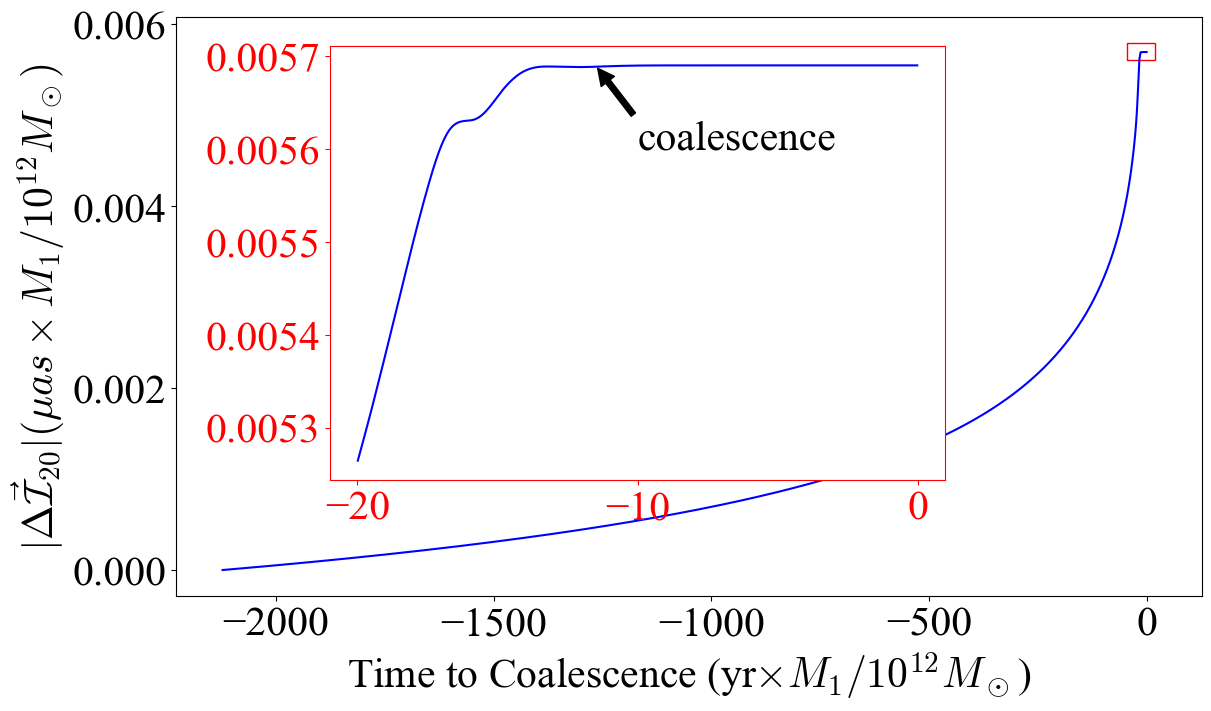

In [3]:
DelphiIMRI1e10vs3p3e9=np.load("DeltaPhiIMRI1.0e+12msun1.0e+10msun0.8Spin1.npy",allow_pickle=True).item()
times=DelphiIMRI1e10vs3p3e9['time']
DelPhi20=DelphiIMRI1e10vs3p3e9['[2,0]']

length=len(times)

fig,ax=plt.subplots(constrained_layout=True)

final_time=times[-1]
print(final_time)
ax.plot((times-final_time)/3600/24/365.25,abs(DelPhi20)*ratio,'b')

# inset
time0=final_time-20*3600*24*365.25
time1=time0+20*3600*24*365.25
mask=(times>time0)&(times<time1)
axins=ax.inset_axes([0.15, 0.2, 0.6, 0.75])
axins.plot((times[mask]-final_time)/3600/24/365.25,abs(DelPhi20[mask])*ratio,'b')
# change inset axes color
axins.spines['bottom'].set_color('red')
axins.spines['top'].set_color('red')
axins.spines['left'].set_color('red')
axins.spines['right'].set_color('red')
axins.tick_params(axis='x', colors='red')
axins.tick_params(axis='y', colors='red')

# rect
rect=plt.Rectangle(((time0*0.8-final_time)/3600/24/365.25/10, 0.0056), 2.0e9/3600/24/365.25, max(abs(DelPhi20[mask])*ratio/30), edgecolor='red', facecolor='none')

ax.add_patch(rect)

# annotation
axins.annotate("coalescence", xy=(-11.5, 0.00569),xytext=(-10, 0.0056),arrowprops=dict(facecolor='black', shrink=0.05), color='black')

ax.set_xlabel(r"Time to Coalescence (yr$\times{M_1}/{10^{12}M_\odot}$)")
ax.set_ylabel(r"$|\Delta \vec\mathcal{I}_{20}| (\mu as\times{M_1}/{10^{12}M_\odot})$")
plt.savefig("../imesim.pdf", dpi=300)
plt.show()

## Figure 4

[1.e+10 1.e+12 1.e+14 1.e+16 1.e+18 1.e+20]


/tmp/ipykernel_3003/2472987029.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0,0.01,1,0.95])


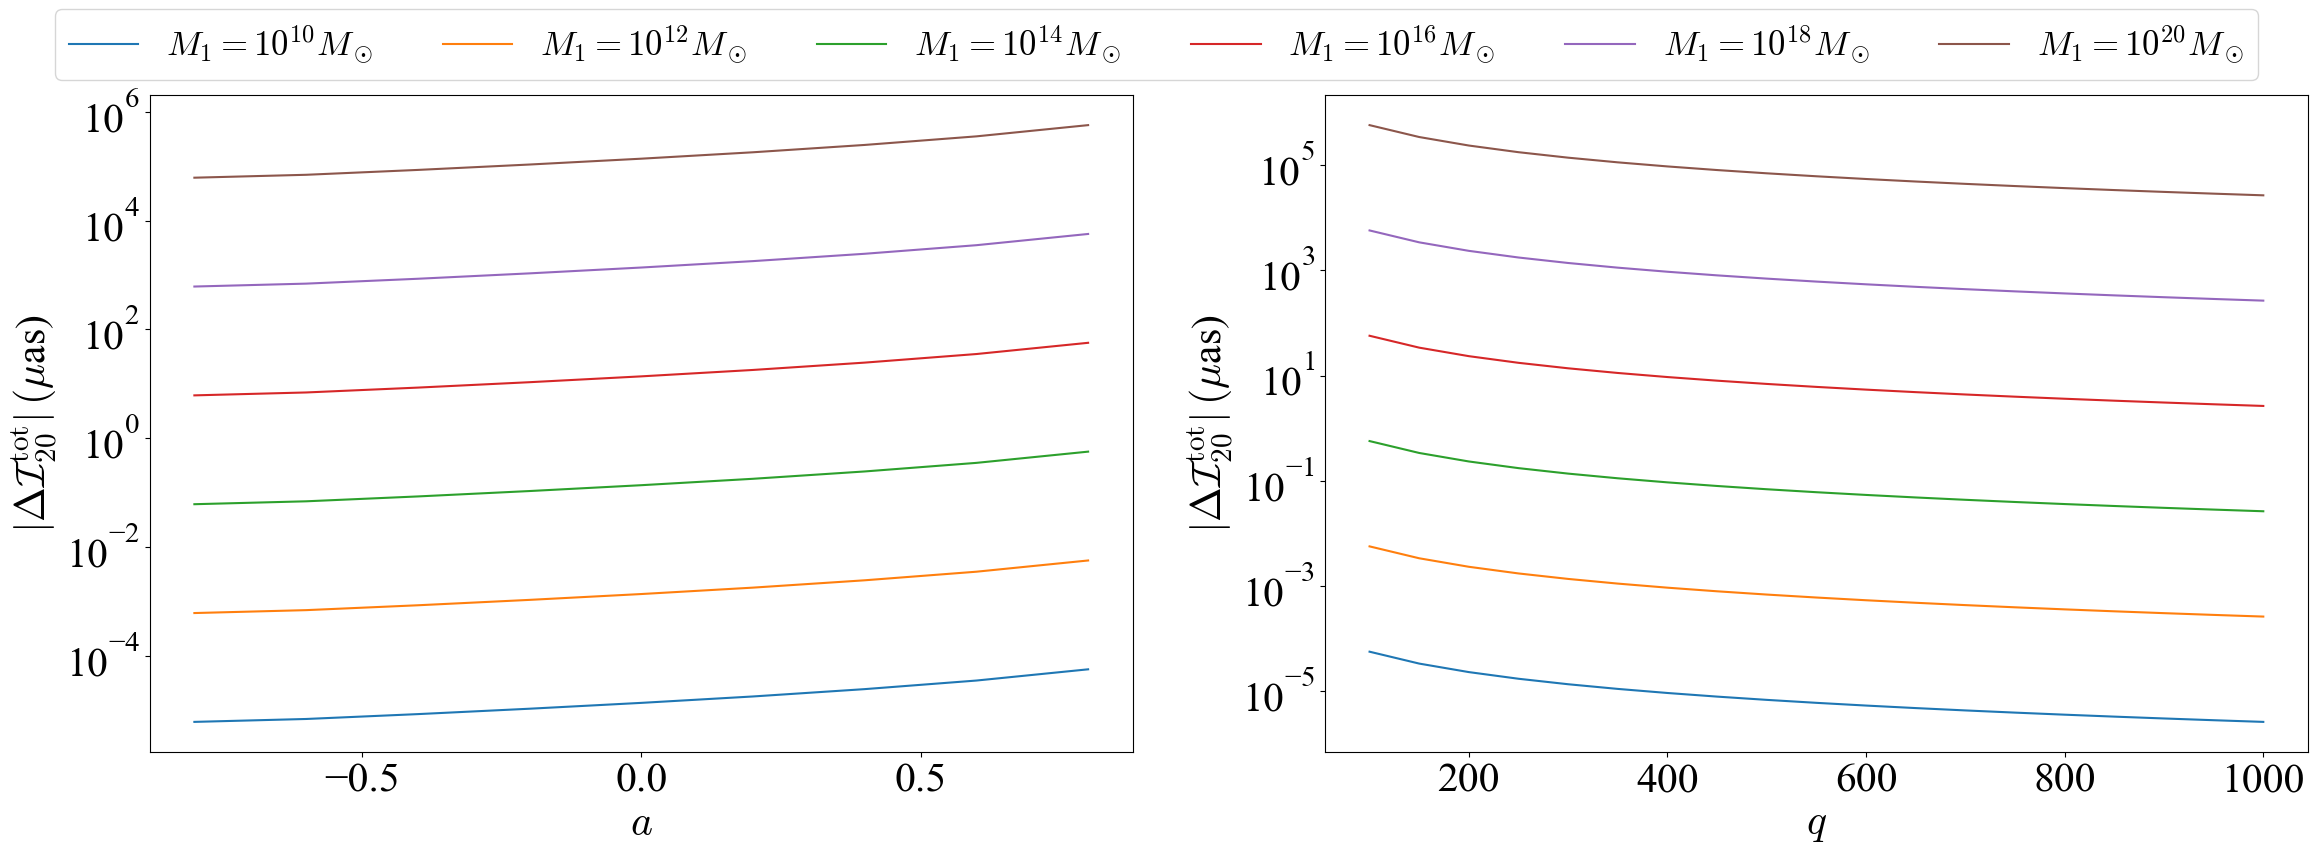

In [ ]:
pow_in=10
stepsize=2
pows=np.array([1.e+10, 1.e+12, 1.e+14, 1.e+16, 1.e+18, 1.e+20])
labels=[r'$M_1=10^{10}M_\odot$', r'$M_1=10^{12}M_\odot$', r'$M_1=10^{14}M_\odot$', r'$M_1=10^{16}M_\odot$', r'$M_1=10^{18}M_\odot$', r'$M_1=10^{20}M_\odot$']

fig,ax=plt.subplots(1,2,figsize=(24,9),constrained_layout=True)

for idx,pow in enumerate(pows):
    fname=f"IMRImaxVsChimsun{pow:.1e}q1.0e+02.txt"
    data=np.loadtxt(fname)
    logpow=np.log10(pow)

    ax[0].plot(data[:,0],data[:,1],label=labels[idx])

    fname=f"IMRImaxVsQmun1{pow:.1e}spin10.8.txt"
    data=np.loadtxt(fname)

    ax[1].plot(data[:,0],data[:,1])

ax[0].set_yscale("log")
ax[0].set_xlabel(r"$a$")
ax[0].set_ylabel(r'$|\Delta\mathcal{I}^\text{tot}_{20}|\, (\mu$as)')

ax[1].set_yscale("log")
ax[1].set_xlabel(r"$q$")
ax[1].set_ylabel(r'$|\Delta\mathcal{I}^\text{tot}_{20}|\, (\mu$as)')

# place a common legend at the bottom 
fig.legend(loc="upper center", bbox_to_anchor=(0.50, 1.01), ncol=6,fontsize=25)
ax[0].legend().remove()

plt.tight_layout(rect=[0,0.01,1,0.95])
plt.savefig('../totimevsqs1.pdf')
plt.show()
